# Gesture Recognition - Model Training

This notebook handles model definition, training, and evaluation.

**Output:** Trained model weights (.pth)

## 1. Environment Setup

In [1]:
# Check GPU
!nvidia-smi

Sun Apr  5 05:58:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.14              Driver Version: 550.54.14      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3080 Ti     Off |   00000000:21:00.0 Off |                  N/A |
| 30%   21C    P8             22W /  350W |    1984MiB /  12288MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
import json
import random
from collections import defaultdict

import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import matplotlib.pyplot as plt

# Import from common module
from common import (
    # Constants
    SEQ_LEN,
    NUM_LANDMARKS,
    NUM_COORDS,
    RAW_DIM,
    NUM_CLASSES,
    CLASS_NAMES,
    CACHE_VERSION,
    FEATURE_DIM,
    # Logging
    log_info,
    log_warn,
    # Environment
    setup_environment,
    get_save_dir,
    get_device,
    # Utils
    to_scalar,
    resample,
    to_raw_sequence,
    # Features
    compute_features,
    # Augmentation
    add_jitter,
    time_warp,
    # Model
    GestureTCN,
    count_parameters,
    # Dataset
    GestureDataset,
    compute_class_weights,
    make_sampler,
    # Evaluation
    evaluate,
)

# Training hyperparameters
BATCH_SIZE = 32
EPOCHS = 300
LR = 2e-3
WEIGHT_DECAY = 1e-3
PATIENCE = 40

## 2. Environment Setup and Load Dataset Info

In [3]:
# Setup environment and get paths
env = setup_environment()
save_dir = get_save_dir()
DEVICE = get_device()

print(f"Environment: {env}")
print(f"Device: {DEVICE}")

Environment: hpc
Device: cuda


In [4]:
# Load dataset info
info_path = os.path.join(save_dir, "dataset_info.json")

with open(info_path, "r", encoding="utf-8") as f:
    dataset_info = json.load(f)

# Verify constants match
assert SEQ_LEN == dataset_info["seq_len"], "SEQ_LEN mismatch"
assert FEATURE_DIM == dataset_info["feature_dim"], "FEATURE_DIM mismatch"
assert NUM_CLASSES == dataset_info["num_classes"], "NUM_CLASSES mismatch"

print(f"Feature dim: {FEATURE_DIM}")
print(f"Classes: {CLASS_NAMES}")

Feature dim: 144
Classes: ['grab', 'release', 'swipe_up', 'swipe_down', 'noise']


## 3. Load Preprocessed Data

In [7]:
# Load cache
from common.dataset import load_cache

cache_dir = os.path.join(save_dir, "cache")
tr_cache = os.path.join(cache_dir, f"train_{CACHE_VERSION}.npz")
te_cache = os.path.join(cache_dir, f"test_{CACHE_VERSION}.npz")

train_samples, train_labels = load_cache(tr_cache)
test_samples, test_labels = load_cache(te_cache)

print(f"Train samples: {len(train_samples)}")
print(f"Test samples: {len(test_samples)}")

Train samples: 3018
Test samples: 29


In [8]:
# Load normalization stats
norm_stats = torch.load(os.path.join(save_dir, "norm_stats.pt"), weights_only=False)
print(
    f"Loaded norm_stats: mean shape={norm_stats['mean'].shape}, std shape={norm_stats['std'].shape}"
)

Loaded norm_stats: mean shape=(144,), std shape=(144,)


## 4. PyTorch Dataset and DataLoader

In [11]:
# Create dataloaders
class_weights = compute_class_weights(train_labels)
print(f"Class weights: {class_weights.numpy().round(3)}")

sampler = make_sampler(train_labels)
train_dataset = GestureDataset(train_samples, train_labels, norm_stats, augment=True)
test_dataset = GestureDataset(test_samples, test_labels, norm_stats, augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Class weights: [0.969 0.867 1.259 1.016 0.889]
Train batches: 95
Test batches: 1


## 5. Model Definition (GestureTCN - Imported from common)

In [13]:
# Create model
model = GestureTCN(NUM_CLASSES, FEATURE_DIM, dropout=0.15).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"Model params: {total_params:,}")
print(model)

Model params: 87,077
GestureTCN(
  (stem): Sequential(
    (0): Conv1d(144, 48, kernel_size=(1,), stride=(1,), bias=False)
    (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (blocks): Sequential(
    (0): ResBlock(
      (net): Sequential(
        (0): CausalConv1d(
          (conv): Conv1d(48, 48, kernel_size=(3,), stride=(1,), padding=(2,), bias=False)
        )
        (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Dropout(p=0.15, inplace=False)
        (4): CausalConv1d(
          (conv): Conv1d(48, 48, kernel_size=(3,), stride=(1,), padding=(2,), bias=False)
        )
        (5): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (act): ReLU(inplace=True)
    )
    (1): ResBlock(
      (net): Sequential(
        (0): CausalConv1d(
          (conv): Conv1d(48, 48, kernel_size=(3,), stri

## 6. Training Loop

In [15]:
# Training setup
ckpt_path = os.path.join(save_dir, "gesture_tcn_best.pth")

# Loss and optimizer
try:
    criterion = nn.CrossEntropyLoss(
        weight=class_weights.to(DEVICE), label_smoothing=0.1
    )
except TypeError:
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

best_acc = -1.0
best_epoch = 0
patience_ctr = 0

# For plotting
train_losses = []
test_losses = []
train_accs = []
test_accs = []
learning_rates = []

In [16]:
# Training loop
log_info("Training ...")

for epoch in range(1, EPOCHS + 1):
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    for bx, by in train_loader:
        bx, by = bx.to(DEVICE), by.to(DEVICE)
        optimizer.zero_grad()
        logits = model(bx)
        loss = criterion(logits, by)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        optimizer.step()
        t_loss += loss.item() * bx.size(0)
        t_correct += (logits.argmax(1) == by).sum().item()
        t_total += bx.size(0)

    scheduler.step()

    tr_loss = t_loss / max(t_total, 1)
    tr_acc = t_correct / max(t_total, 1)
    te_loss, te_acc, _, _ = evaluate(model, test_loader, criterion, DEVICE)
    lr_now = optimizer.param_groups[0]["lr"]

    # Record for plotting
    train_losses.append(tr_loss)
    test_losses.append(te_loss)
    train_accs.append(tr_acc)
    test_accs.append(te_acc)
    learning_rates.append(lr_now)

    tag = ""
    if te_acc > best_acc:
        best_acc = te_acc
        best_epoch = epoch
        patience_ctr = 0
        torch.save(model.state_dict(), ckpt_path)
        tag = "  <- best"
    else:
        patience_ctr += 1

    if epoch % 5 == 0 or tag:
        log_info(
            f"Epoch {epoch:>3d}/{EPOCHS} | "
            f"TrL:{tr_loss:.4f} TrA:{tr_acc:.4f} | "
            f"TeL:{te_loss:.4f} TeA:{te_acc:.4f} | "
            f"LR:{lr_now:.2e}{tag}"
        )

    if patience_ctr >= PATIENCE:
        log_info(f"Early stop at epoch {epoch}")
        break

log_info(f"Best test acc: {max(best_acc, 0.0):.4f} @ epoch {best_epoch}")

[05:58:47] INFO - Training ...
[05:58:59] INFO - Epoch   1/300 | TrL:0.7961 TrA:0.8211 | TeL:0.8966 TeA:0.8276 | LR:2.00e-03  <- best
[05:59:07] INFO - Epoch   5/300 | TrL:0.4519 TrA:0.9911 | TeL:0.9091 TeA:0.7931 | LR:2.00e-03
[05:59:09] INFO - Epoch   6/300 | TrL:0.4390 TrA:0.9960 | TeL:0.9137 TeA:0.8621 | LR:2.00e-03  <- best
[05:59:16] INFO - Epoch   9/300 | TrL:0.4275 TrA:0.9967 | TeL:0.7325 TeA:0.8966 | LR:2.00e-03  <- best
[05:59:18] INFO - Epoch  10/300 | TrL:0.4262 TrA:0.9977 | TeL:0.7433 TeA:0.8621 | LR:1.99e-03
[05:59:28] INFO - Epoch  15/300 | TrL:0.4298 TrA:0.9944 | TeL:0.8007 TeA:0.8966 | LR:1.99e-03
[05:59:38] INFO - Epoch  20/300 | TrL:0.4157 TrA:0.9980 | TeL:0.7029 TeA:0.8621 | LR:1.98e-03
[05:59:48] INFO - Epoch  25/300 | TrL:0.4153 TrA:0.9997 | TeL:0.6933 TeA:0.8621 | LR:1.97e-03
[05:59:59] INFO - Epoch  30/300 | TrL:0.4119 TrA:1.0000 | TeL:0.7749 TeA:0.8621 | LR:1.95e-03
[06:00:09] INFO - Epoch  35/300 | TrL:0.4231 TrA:0.9964 | TeL:0.6145 TeA:0.8966 | LR:1.93e-03
[0

## 7. Plot Training Curves

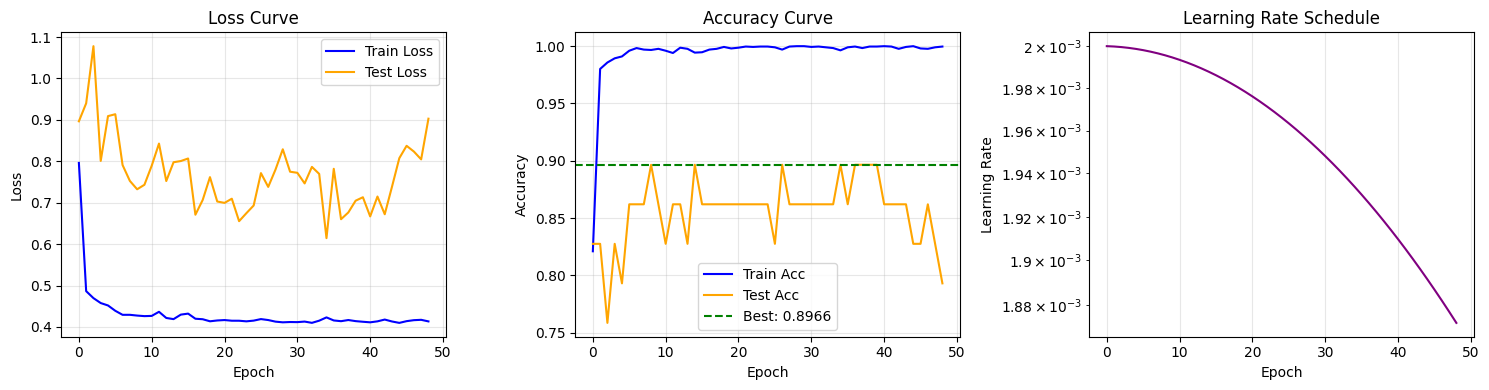

In [17]:
# Plot loss and accuracy curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss curve
axes[0].plot(train_losses, label="Train Loss", color="blue")
axes[0].plot(test_losses, label="Test Loss", color="orange")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(train_accs, label="Train Acc", color="blue")
axes[1].plot(test_accs, label="Test Acc", color="orange")
axes[1].axhline(
    y=best_acc, color="green", linestyle="--", label=f"Best: {best_acc:.4f}"
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy Curve")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate curve
axes[2].plot(learning_rates, color="purple")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Learning Rate")
axes[2].set_title("Learning Rate Schedule")
axes[2].set_yscale("log")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "training_curves.png"), dpi=150)
plt.show()

## 8. Evaluation

In [18]:
# Load best model
model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))

<All keys matched successfully>

In [19]:
log_info("Evaluation ...")
crit = nn.CrossEntropyLoss()
_, te_acc, preds, gts = evaluate(model, test_loader, crit, DEVICE)
log_info(f"Accuracy: {te_acc:.4f}")

# F1 Score
f1_macro = f1_score(gts, preds, average="macro")
f1_weighted = f1_score(gts, preds, average="weighted")
print(f"\nF1 Score (Macro): {f1_macro:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")

# Classification Report
label_ids = list(range(NUM_CLASSES))
if len(gts) > 0:
    print("\nClassification Report:")
    print(
        classification_report(
            gts,
            preds,
            labels=label_ids,
            target_names=CLASS_NAMES,
            digits=4,
            zero_division=0,
        )
    )

    # Confusion Matrix
    cm = confusion_matrix(gts, preds, labels=label_ids)
    print("\nConfusion Matrix:")
    hdr = "          " + "  ".join(f"{n[:6]:>6s}" for n in CLASS_NAMES)
    print(hdr)
    for i, row in enumerate(cm):
        print(f"  {CLASS_NAMES[i][:8]:>8s}  " + "  ".join(f"{v:>6d}" for v in row))

[06:00:42] INFO - Evaluation ...
[06:00:42] INFO - Accuracy: 0.8966

F1 Score (Macro): 0.8981
F1 Score (Weighted): 0.8954

Classification Report:
              precision    recall  f1-score   support

        grab     1.0000    0.6667    0.8000         6
     release     1.0000    1.0000    1.0000         6
    swipe_up     0.7143    1.0000    0.8333         5
  swipe_down     1.0000    1.0000    1.0000         5
       noise     0.8571    0.8571    0.8571         7

    accuracy                         0.8966        29
   macro avg     0.9143    0.9048    0.8981        29
weighted avg     0.9163    0.8966    0.8954        29


Confusion Matrix:
            grab  releas  swipe_  swipe_   noise
      grab       4       0       1       0       1
   release       0       6       0       0       0
  swipe_up       0       0       5       0       0
  swipe_do       0       0       0       5       0
     noise       0       0       1       0       6


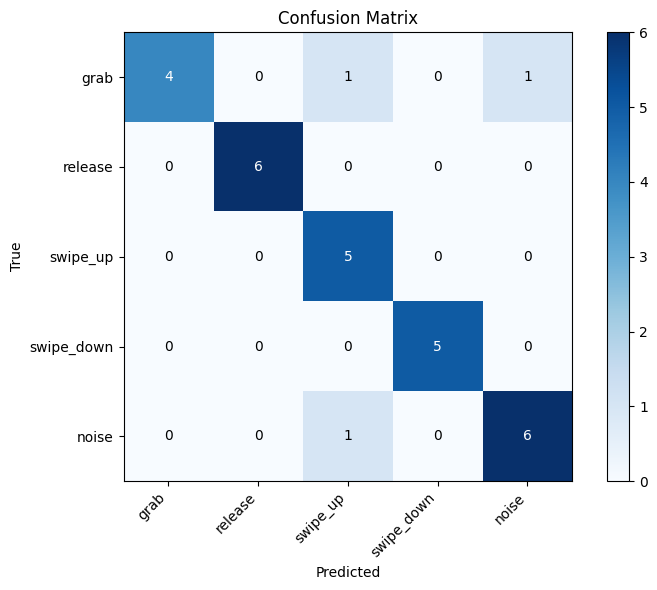

In [20]:
# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix")

# Add values
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        text = ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
        )

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "confusion_matrix.png"), dpi=150)
plt.show()

## 9. Save Model Weights

In [21]:
# Save best model
best_path = os.path.join(save_dir, "gesture_tcn_best.pth")
torch.save(model.state_dict(), best_path)
log_info(f"Saved model to {best_path}")

# Save training history
history = {
    "train_losses": train_losses,
    "test_losses": test_losses,
    "train_accs": train_accs,
    "test_accs": test_accs,
    "learning_rates": learning_rates,
    "best_epoch": best_epoch,
    "best_acc": best_acc,
    "f1_macro": f1_macro,
    "f1_weighted": f1_weighted,
}
history_path = os.path.join(save_dir, "training_history.json")
with open(history_path, "w") as f:
    json.dump(history, f, indent=2)
log_info(f"Saved training history to {history_path}")

[06:00:44] INFO - Saved model to checkpoints/gesture_tcn_best.pth
[06:00:44] INFO - Saved training history to checkpoints/training_history.json


In [ ]:
# Copy to Google Drive if in Colab
from common import detect_environment

if detect_environment() == "colab":
    import shutil

    drive_path = "/content/drive/MyDrive/checkpoints"
    shutil.copytree("checkpoints", drive_path, dirs_exist_ok=True)
    print(f"Files copied to: {drive_path}")
else:
    print("Skipping copy to Drive (not in Colab environment)")

Skipping copy to Drive (not in Colab environment)


## Summary

This notebook has:
1. Loaded preprocessed data from cache
2. Defined the GestureTCN model
3. Trained the model with early stopping
4. Plotted loss and accuracy curves
5. Evaluated the model with F1 score, classification report, and confusion matrix
6. Saved the best model weights

**Output files:**
- `checkpoints/gesture_tcn_best.pth` - Best model weights
- `checkpoints/training_curves.png` - Training visualization
- `checkpoints/confusion_matrix.png` - Confusion matrix
- `checkpoints/training_history.json` - Training history